# Train Route Analysis and Journey 


## Level 1 : Data Overview

### Task 1.1 Load the Dataset

In [1]:
import pandas as pd

train_route = pd.read_csv("Train_Route_Analysis.csv")

train_route.shape

train_route.info()

<class 'pandas.DataFrame'>
RangeIndex: 186074 entries, 0 to 186073
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   SN              186074 non-null  int64
 1   Train_No        186074 non-null  int64
 2   Station_Code    186074 non-null  str  
 3   1A              186074 non-null  int64
 4   2A              186074 non-null  int64
 5   3A              186074 non-null  int64
 6   SL              186074 non-null  int64
 7   Station_Name    186074 non-null  str  
 8   Route_Number    186074 non-null  int64
 9   Arrival_time    186074 non-null  str  
 10  Departure_Time  186074 non-null  str  
 11  Distance        186074 non-null  int64
dtypes: int64(8), str(4)
memory usage: 17.0 MB


### Task 1.2 Train-wise Route Table

In [2]:
route_table = train_route[['Train_No', 'Station_Name', 'Distance']]
route_table.head()

,Train_No,Station_Name,Distance
0,107,SAWANTWADI R,0
1,107,THIVIM,32
2,107,KARMALI,49
3,107,MADGOAN JN.,78
4,108,MADGOAN JN.,0


### Task 1.3 Basic Statistics

In [3]:
train_route[['Distance', 'Station_Code']].describe()

,Distance
count,186074.000000
mean,281.353838
std,483.743964
min,0.000000
25%,23.000000
50%,73.000000
75%,291.000000
max,4260.000000


### Task 1.4 Missing and Inconsistent Values

#### Check missing values

In [4]:
train_route.isnull().sum()

SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64

#### Check duplicate rows


In [5]:
train_route.duplicated().sum()

np.int64(0)

## Level 2: Data Cleaning & Feature Engineering

### Handling Missing Values

In [6]:
train_route.isnull().sum()

SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64

In [7]:
train_route['Arrival_time'] = train_route['Arrival_time'].ffill()
train_route['Departure_Time'] = train_route['Departure_Time'].ffill()

train_route.dropna(subset=['Train_No', 'Station_Code', 'Distance'], inplace=True)

In [8]:
train_route.drop_duplicates(inplace=True)

### Task 2.2 Standardize Arrival & Departure Time Formats

#### Converted to datetime format

In [9]:
train_route['Arrival_time'] = pd.to_datetime(
    train_route['Arrival_time'],
    format='%H:%M:%S',
    errors='coerce'
)

train_route['Departure_Time'] = pd.to_datetime(
    train_route['Departure_Time'],
    format='%H:%M:%S',
    errors='coerce'
)

#### Extracted Time Components

In [10]:
train_route['Arrival_hour'] = train_route['Arrival_time'].dt.hour
train_route['Departure_hour'] = train_route['Departure_Time'].dt.hour

### Task 2.3 Calculate Total Journey Duration

In [11]:
train_route['journey_duration'] = (
    train_route['Departure_Time'] - train_route['Arrival_time']
)

train_route['journey_hours'] = (
    train_route['journey_duration'].dt.total_seconds() / 3600
)

#### For total duration per train

In [12]:
train_duration = train_route.groupby('Train_No')['journey_hours'].sum().reset_index()

### Task 2.4 Create New Features

#### Total Distance per Train

In [13]:
total_distance = train_route.groupby('Train_No')['Distance'].max().reset_index()

#### Number of Stops per Train

In [14]:
number_of_stops = train_route.groupby('Train_No')['Station_Code'].count().reset_index()
number_of_stops.rename(columns={'Station_Code': 'total_stops'}, inplace=True)

#### Average Speed (New Advanced Feature)

In [15]:
train_route['avg_speed'] = train_route['Distance'] / train_route['journey_hours']

## Level 3: Data Exploration

### Task 3.1 Compare Journey Duration Across Different Routes

#### Average journey duration per route

In [16]:
route_duration = train_route.groupby('Route_Number')['journey_hours'].mean().sort_values()

In [17]:
print(route_duration)

Route_Number
1    0.018056
Name: journey_hours, dtype: float64


### Task 3.2 Identify Stations with High and Low Train Traffic

#### Count trains per station

In [18]:
station_traffic = train_route['Station_Name'].value_counts()

In [19]:
print("Top 10 High Traffic Stations:")
print(station_traffic.head(10))


Top 10 High Traffic Stations:
Station_Name
CST-MUMBAI      1027
KALYAN JN        828
THANE            796
SEALDAH          745
CHENNAI BEAC     738
HOWRAH JN.       699
DADAR            598
DUM DUM JN.      463
KURLA            462
TAMBARAM         434
Name: count, dtype: int64


In [20]:
print("\nTop 10 Low Traffic Stations:")
print(station_traffic.tail(10))


Top 10 Low Traffic Stations:
Station_Name
SALGAJHARI         1
KARCHIYA YAR       1
DOMBIVLI CTL       1
NEW RUNNISAI       1
AWAPUR F           1
BACHHARPUR H       1
BANDRA             1
AMBALA CANT JN     1
LUDHIANA JN        1
SHMATA VD KATRA    1
Name: count, dtype: int64


### Task 3.3 Relationship Between Distance and Journey Duration

Correlation between Distance and Journey Hours: -0.01574328883705827


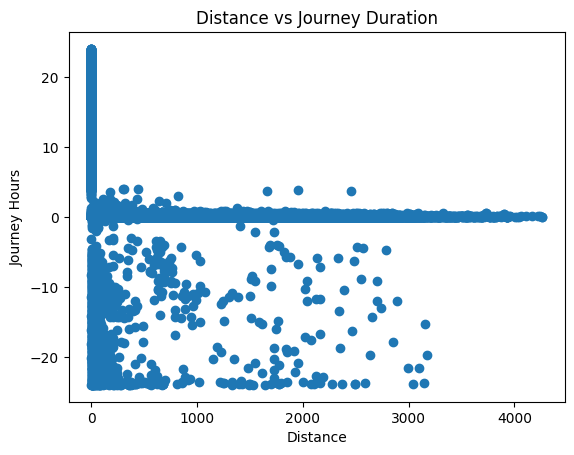

In [21]:
import matplotlib.pyplot as plt

correlation = train_route['Distance'].corr(train_route['journey_hours'])
print("Correlation between Distance and Journey Hours:", correlation)

plt.figure()
plt.scatter(train_route['Distance'], train_route['journey_hours'])
plt.xlabel("Distance")
plt.ylabel("Journey Hours")
plt.title("Distance vs Journey Duration")
plt.show()

## Level 4: Visualization & Pattern Analysis

### Task 4.1 Visualize Journey Duration Across Different Routes

In [22]:
route_avg = train_route.groupby('Route_Number')['journey_hours'].mean().reset_index()

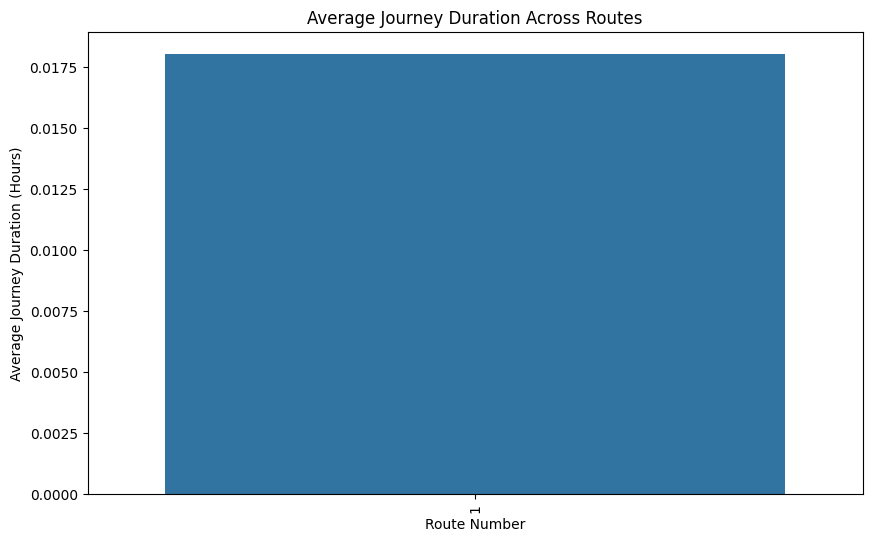

In [23]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(data=route_avg, x='Route_Number', y='journey_hours')

plt.xticks(rotation=90)
plt.title("Average Journey Duration Across Routes")
plt.xlabel("Route Number")
plt.ylabel("Average Journey Duration (Hours)")
plt.show()

### Task 4.2 Station-wise Train Traffic Visualization

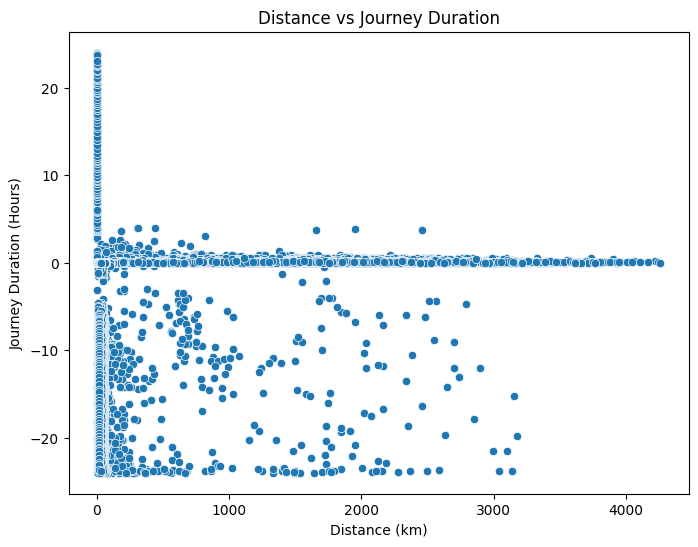

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=train_route, x='Distance', y='journey_hours')

plt.title("Distance vs Journey Duration")
plt.xlabel("Distance (km)")
plt.ylabel("Journey Duration (Hours)")
plt.show()

## Level 5: Prediction Model Development

### Task 5.1 Prepare Modeling Dataset

#### Clean Column Names

In [25]:
train_route.columns = train_route.columns.str.lower()
print(train_route.columns)

Index(['sn', 'train_no', 'station_code', '1a', '2a', '3a', 'sl',
       'station_name', 'route_number', 'arrival_time', 'departure_time',
       'distance', 'arrival_hour', 'departure_hour', 'journey_duration',
       'journey_hours', 'avg_speed'],
      dtype='str')


#### Rename main station column

In [26]:
train_route.rename(columns={'station_name_x_x_x': 'station_name'}, inplace=True)

In [27]:
print(train_route.columns)

Index(['sn', 'train_no', 'station_code', '1a', '2a', '3a', 'sl',
       'station_name', 'route_number', 'arrival_time', 'departure_time',
       'distance', 'arrival_hour', 'departure_hour', 'journey_duration',
       'journey_hours', 'avg_speed'],
      dtype='str')


####  Create number of stops per route

In [28]:
stops_per_route = train_route.groupby('route_number')['station_name'].count().reset_index()
stops_per_route.rename(columns={'station_name': 'number_of_stops'}, inplace=True)

#### Merge back

In [29]:
train_route = train_route.merge(stops_per_route, on='route_number', how='left')

In [30]:
print(train_route.head())

   sn  train_no station_code   1a   2a   3a   sl  station_name  route_number  \
0   1       107          SWV  100  100  100  100  SAWANTWADI R             1   
1   2       107         THVM  260  228  196  164        THIVIM             1   
2   3       107         KRMI  345  296  247  198       KARMALI             1   
3   4       107          MAO  490  412  334  256   MADGOAN JN.             1   
4   1       108          MAO  100  100  100  100   MADGOAN JN.             1   

         arrival_time      departure_time  distance  arrival_hour  \
0 1900-01-01 00:00:00 1900-01-01 10:25:00         0             0   
1 1900-01-01 11:06:00 1900-01-01 11:08:00        32            11   
2 1900-01-01 11:28:00 1900-01-01 11:30:00        49            11   
3 1900-01-01 12:10:00 1900-01-01 00:00:00        78            12   
4 1900-01-01 00:00:00 1900-01-01 20:30:00         0             0   

   departure_hour  journey_duration  journey_hours    avg_speed  \
0              10   0 days 10:25:00  

In [31]:
print(train_route.columns)

Index(['sn', 'train_no', 'station_code', '1a', '2a', '3a', 'sl',
       'station_name', 'route_number', 'arrival_time', 'departure_time',
       'distance', 'arrival_hour', 'departure_hour', 'journey_duration',
       'journey_hours', 'avg_speed', 'number_of_stops'],
      dtype='str')


In [32]:
X = train_route[['distance', 'number_of_stops']]
y = train_route['journey_hours']

print(X.head())

   distance  number_of_stops
0         0           186074
1        32           186074
2        49           186074
3        78           186074
4         0           186074


### Task 5.2 Train-Test Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (148859, 2)
Testing size: (37215, 2)


### Task 5.3 Build Linear Regression Model

In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Task 5.4 Evaluate Model Performance

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.353714360670567
RMSE: 2.288479376934555


## Level 6: Final Data Science Project

### Step 6.1 Build Complete Prediction System

#### Import Libraries

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

#### Train Linear Regression Model

In [37]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

#### Model Evaluation

In [38]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.353714360670567
RMSE: 2.288479376934555


### Step 6.2 Visualize Actual vs Predicted

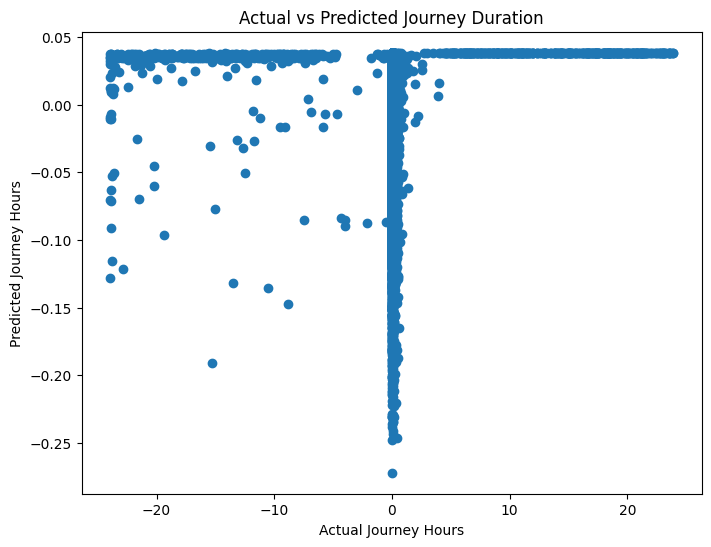

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Journey Hours")
plt.ylabel("Predicted Journey Hours")
plt.title("Actual vs Predicted Journey Duration")
plt.show()